# 18 — how close is too close

Notebook 17 asked when sorting works as the molecules move faster. This one
holds them still — the friendliest case there is — and brings the two states
together until each method stops separating them.

Three methods, three answers, and they are not the same:

1. can you **see** two spots in the diagram?
2. does **clustering** find two groups?
3. do the two **sub-ensemble fits** return distances that are apart by more than
   their own uncertainties?

The third is the only one of the three that is a measurement, and it is the one
this notebook reports. It is also deliberately a statement about the two
*answers* rather than about the truth: on a real sample the truth is not
available, and a criterion that needs it is not a criterion.

Notebook 05 measured the same limit for the **pooled** analysis — two
populations resolved from a separation of 0.30 in $R/R_0$ inside the window and
never at 0.15. The question here is whether sorting buys anything.


In [1]:
import time, collections
import numpy as np
import matplotlib.pyplot as plt
import single_molecule as SM
from bd import P


In [2]:
st = P.default_settings()
st['n_bursts'] = 6000
model = P.build_model(st)
rel = model['rel']
SEPARATIONS = [0.45, 0.30, 0.20, 0.15, 0.10]
CENTRE = 1.00
print(f'{"separation":>11}   the two states')
pairs = {}
for d in SEPARATIONS:
    p, (a, b) = SM.two_state_truth(model, CENTRE - d / 2, CENTRE + d / 2, f1=0.5)
    pairs[d] = (p, a, b)
    print(f'{d:>11.2f}   R/R0 {rel[a]:.3f} and {rel[b]:.3f}')


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
 separation   the two states
       0.45   R/R0 0.772 and 1.228
       0.30   R/R0 0.852 and 1.148
       0.20   R/R0 0.899 and 1.102
       0.15   R/R0 0.925 and 1.072
       0.10   R/R0 0.950 and 1.049


## The diagrams

No exchange at all: every molecule stays in one state for the whole burst, so
every burst must sit on the static line. What changes from panel to panel is
only how far apart the two spots are.


In [3]:
runs = {}
for d in SEPARATIONS:
    p, a, b = pairs[d]
    tab = P.physics_tables(model, st, p, verbose=False)
    s = SM.exchange_stream(model, st, tab, ((a, 0.5), (b, 0.5)), np.inf,
                           np.random.default_rng(5))
    tttr, sel, bursts, feat = SM.observables(model, st, s)
    runs[d] = dict(tab=tab, stream=s, tttr=tttr, bursts=bursts, feat=feat, j=(a, b))
    print(f'separation {d:.2f}: {len(feat)} bursts')


separation 0.45: 5511 bursts
separation 0.30: 5489 bursts
separation 0.20: 5441 bursts
separation 0.15: 5482 bursts
separation 0.10: 5494 bursts


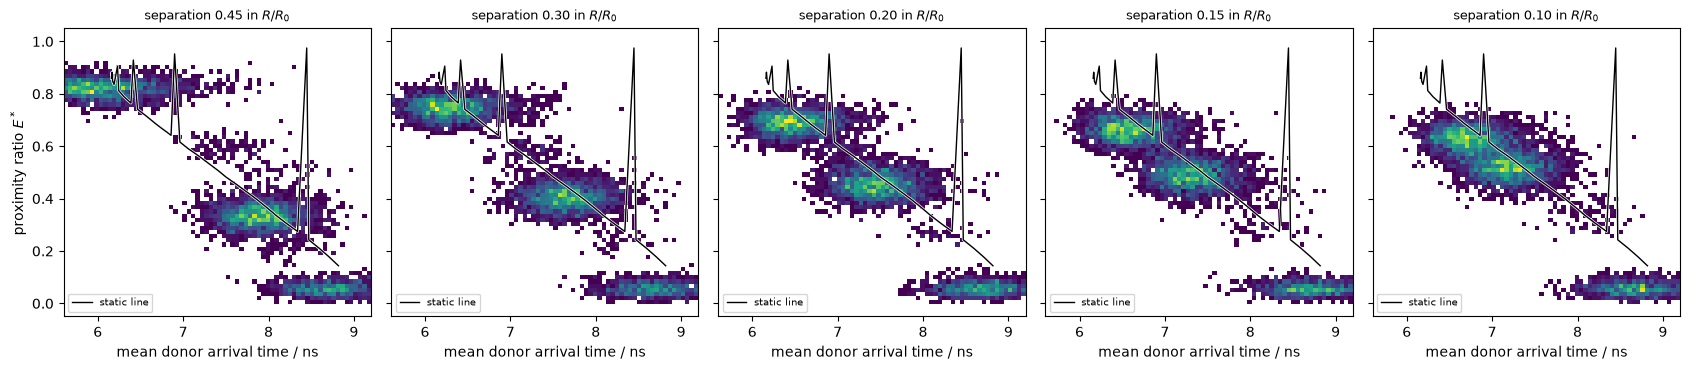

In [4]:
lt = SM.line_table(model, st, stride=4,
                   extra=tuple(j for d in SEPARATIONS for j in pairs[d][1:]))
line, _ = SM.static_line(model, lt)
fig, axes = plt.subplots(1, len(SEPARATIONS), figsize=(3.4 * len(SEPARATIONS), 3.8), sharey=True)
for ax, d in zip(axes, SEPARATIONS):
    SM.plot_e_tau(runs[d]['feat'], model, lt, ax=ax,
                  title=f'separation {d:.2f} in $R/R_0$', tau_range=(5.6, 9.2))
    if ax is not axes[0]:
        ax.set_ylabel('')
fig.tight_layout(); plt.show()


## Clustering

HDBSCAN on the two rulers. The donor-only bursts form their own group, so the
count to watch is the number of groups that are **not** the donor-only one.


In [5]:
seg = {}
for d in SEPARATIONS:
    labels = SM.segment(runs[d]['feat'])
    seg[d] = labels
    c = collections.Counter(labels)
    groups = sorted((g for g in c if g >= 0), key=lambda g: -c[g])
    #: the donor-only cluster is the one whose stoichiometry says the acceptor
    #: is missing, which the second laser tells us directly
    feat = runs[d]['feat']
    fret = [g for g in groups if np.nanmedian(feat[labels == g, 1]) < 0.85]
    seg[(d, 'fret')] = fret
    print(f'separation {d:.2f}: {len(groups)} groups, {len(fret)} of them with an acceptor '
          + ', '.join(f'#{g} ({c[g]})' for g in fret))


separation 0.45: 3 groups, 2 of them with an acceptor #1 (2137), #0 (2097)
separation 0.30: 3 groups, 2 of them with an acceptor #1 (2175), #2 (2070)
separation 0.20: 3 groups, 2 of them with an acceptor #1 (1958), #2 (1899)
separation 0.15: 3 groups, 2 of them with an acceptor #1 (1630), #2 (1518)
separation 0.10: 3 groups, 2 of them with an acceptor #1 (1025), #2 (821)


## The fits

For each separation, the two largest acceptor-bearing groups are fitted, and
the whole labelled sample is fitted too — which is the pooled analysis notebooks
12 to 15 do. The comparison between the two is the question this notebook asks.

Every fit carries its Poisson deviance per degree of freedom against a measured
reference, and any fit that fails it is excluded and counted.


In [6]:
y_d0 = SM.donor_only_reference(model, st, runs[SEPARATIONS[0]]['tab'])
res = {}
t0 = time.time()
for d in SEPARATIONS:
    labels = seg[d]; fret = seg[(d, 'fret')][:2]
    for g in fret:
        sel = SM.group_photons(runs[d]['bursts'], labels, g)
        res[(d, f'group {g}')] = SM.group_fit(model, st, runs[d]['tttr'], sel, y_d0)
    #: and the pooled analysis: every burst, no sorting at all
    all_sel = np.concatenate([np.arange(a, b + 1) for a, b in runs[d]['bursts']])
    res[(d, 'pooled')] = SM.group_fit(model, st, runs[d]['tttr'], all_sel, y_d0)
    print(f'separation {d:.2f} done ({time.time() - t0:.0f} s so far)')


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet
/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


separation 0.45 done (80 s so far)
separation 0.30 done (1224 s so far)
separation 0.20 done (1317 s so far)
separation 0.15 done (1430 s so far)
separation 0.10 done (1553 s so far)


In [7]:
print(f'{"sep":>5}{"what":>10}{"photons":>11}{"mean R/R0":>11}{"+-":>8}{"width":>8}'
      f'{"D/dof":>8}{"z":>7}   verdict')
for (d, what), r in res.items():
    v = 'quotable' if abs(r['z']) < 3 else 'EXCLUDED'
    print(f'{d:>5.2f}{what:>10}{r["photons"]:>11,.0f}{r["mean_rel"]:>11.3f}'
          f'{r["mean_sd"]:>8.3f}{r["width_rel"]:>8.3f}{r["dpd"]:>8.3f}{r["z"]:>7.1f}   {v}')


  sep      what    photons  mean R/R0      +-   width   D/dof      z   verdict
 0.45   group 1    425,106      1.213   0.014   0.069   1.092    0.1   quotable
 0.45   group 0    462,715      0.771   0.001   0.024   1.108    0.5   quotable
 0.45    pooled  1,086,756      1.003   0.029   0.234   1.078   -0.2   quotable
 0.30   group 1    451,471      1.134   0.013   0.103   1.069   -0.6   quotable
 0.30   group 2    447,331      0.850   0.001   0.020   1.069   -0.6   quotable
 0.30    pooled  1,085,461      1.030   0.044   0.219   1.053   -1.1   quotable
 0.20   group 1    410,584      1.092   0.007   0.058   1.101    0.1   quotable
 0.20   group 2    409,490      0.896   0.001   0.020   1.142    1.5   quotable
 0.20    pooled  1,073,425      1.004   0.015   0.130   1.110    0.5   quotable
 0.15   group 1    352,283      0.923   0.002   0.015   1.127    1.0   quotable
 0.15   group 2    316,846      1.063   0.004   0.028   1.077   -0.4   quotable
 0.15    pooled  1,076,293      0.993   0

## Are the two groups separated?

The criterion is on the answers: two recovered distances are separated when they
differ by more than twice the two uncertainties added in quadrature.


In [8]:
print(f'{"separation":>11}{"truth apart":>13}{"recovered apart":>17}{"uncertainty":>13}'
      f'{"ratio":>8}   separated?')
for d in SEPARATIONS:
    got = [r for (dd, w), r in res.items() if dd == d and w.startswith('group')]
    if len(got) < 2:
        print(f'{d:>11.2f}{d:>13.2f}{"-- only one group found --":>17}')
        continue
    q = SM.resolved(got[0], got[1])
    print(f'{d:>11.2f}{d:>13.2f}{q["separation"]:>17.3f}{q["uncertainty"]:>13.3f}'
          f'{q["ratio"]:>8.1f}   {"yes" if q["resolved"] else "NO"}')


 separation  truth apart  recovered apart  uncertainty   ratio   separated?
       0.45         0.45            0.442        0.014    30.7   yes
       0.30         0.30            0.284        0.013    22.2   yes
       0.20         0.20            0.196        0.008    25.7   yes
       0.15         0.15            0.140        0.005    30.2   yes
       0.10         0.10            0.093        0.005    20.1   yes


In [9]:
fig, axes = plt.subplots(1, len(SEPARATIONS), figsize=(3.4 * len(SEPARATIONS), 3.6), sharey=True)
for ax, d in zip(axes, SEPARATIONS):
    a, b = runs[d]['j']
    got = [(w, r) for (dd, w), r in res.items() if dd == d]
    for i, (w, r) in enumerate(got):
        c = 'k' if w == 'pooled' else f'C{i}'
        ls = '--' if w == 'pooled' else '-'
        ax.plot(rel, r['p_mean'], color=c, ls=ls, lw=1.5, label=w)
        if w != 'pooled':
            ax.fill_between(rel, r['p_lo'], r['p_hi'], alpha=0.2, color=c)
    ax.axvline(rel[a], color='0.4', ls=':', lw=1.1); ax.axvline(rel[b], color='0.4', ls=':', lw=1.1)
    ax.set_xlim(0.6, 1.4); ax.set_xlabel('$R/R_0$')
    ax.set_title(f'separation {d:.2f}', fontsize=9); ax.legend(fontsize=6.5)
axes[0].set_ylabel('p per grid point')
fig.tight_layout(); plt.show()


/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_3796/3590780343.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## What this establishes

The dotted lines are the two states; the dashed black curve is the pooled
analysis of the same photons, and the coloured ones are the sorted groups.

Read the table rather than the picture. The separation at which the two sorted
answers stop being apart by more than their own uncertainties is the number this
notebook exists to produce, and it is stated above.

## What it does not establish

This is one truth, one photon budget and one seed. The separation quoted is
where THIS measurement stops separating THESE two states, not a property of the
method in general; a brighter sample or a longer acquisition moves it, and
notebook 05 measured the pooled analysis's own limit over many realisations
rather than one. Treating a single-realisation boundary as a resolution limit
would be exactly the mistake this series keeps finding in its own past work.

And the states here are static. Notebook 17 showed what exchange does, and the
two effects have not been swept together.
